<a href="https://colab.research.google.com/github/M-Santhoshkumar-2005/ITA0616-MACHINE-LEARNING-SLOT-A-/blob/main/PROBLEM_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

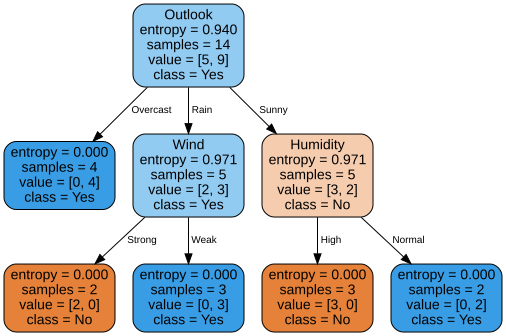

In [8]:
import pandas as pd
import numpy as np
import graphviz
import uuid
from IPython.display import display

# 1. Define the Play Tennis Dataset
df = pd.DataFrame({
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
})

# 2. Mathematical Functions for Entropy and Information Gain
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    return -np.sum([(counts[i]/np.sum(counts)) * np.log2(counts[i]/np.sum(counts)) for i in range(len(elements))])

def info_gain(data, split_attr, target_name="PlayTennis"):
    total_entropy = entropy(data[target_name])
    vals, counts = np.unique(data[split_attr], return_counts=True)
    weighted_entropy = np.sum([(counts[i]/np.sum(counts)) *
                               entropy(data[data[split_attr]==vals[i]][target_name])
                               for i in range(len(vals))])
    return total_entropy - weighted_entropy

# 3. Enhanced ID3 Algorithm (Calculates Scikit-Learn stats at each node)
def build_tree(data, original_data, features, target="PlayTennis"):
    node_entropy = entropy(data[target])
    samples = len(data)

    # Calculate value array [Count of No, Count of Yes]
    val_counts = data[target].value_counts()
    count_no = val_counts.get('No', 0)
    count_yes = val_counts.get('Yes', 0)

    # FIX: Cast to standard integers to remove np.int64() from the display
    value_arr = [int(count_no), int(count_yes)]

    # Determine majority class for the node
    majority_class = 'Yes' if count_yes > count_no else ('No' if count_no > count_yes else 'Tie')

    # Base Cases (Leaf Node)
    if len(np.unique(data[target])) <= 1 or len(data) == 0 or len(features) == 0:
        return {'is_leaf': True, 'entropy': node_entropy, 'samples': samples, 'value': value_arr, 'class': majority_class}

    # Find the best feature
    best_feature = features[np.argmax([info_gain(data, f, target) for f in features])]
    remaining_features = [f for f in features if f != best_feature]

    node = {'is_leaf': False, 'feature': best_feature, 'entropy': node_entropy, 'samples': samples,
            'value': value_arr, 'class': majority_class, 'branches': {}}

    # Create multi-way branches
    for value in np.unique(data[best_feature]):
        sub_data = data[data[best_feature] == value]
        if len(sub_data) > 0:
            node['branches'][value] = build_tree(sub_data, original_data, remaining_features, target)

    return node

# 4. Color formatting mimicking Scikit-Learn (Blue for Yes, Orange for No)
def get_node_color(value_arr):
    no_cnt, yes_cnt = value_arr
    total = no_cnt + yes_cnt
    if total == 0: return "#ffffff"

    p_yes = yes_cnt / total
    if p_yes > 0.5:
        return "#399de5" if p_yes == 1.0 else "#91cbf2" # Deep/Light Blue
    elif p_yes < 0.5:
        return "#e58139" if (no_cnt / total) == 1.0 else "#f6ccae" # Deep/Light Orange
    return "#ffffff" # White for tie

# 5. Render the custom tree in Scikit-Learn format using Graphviz
def draw_sklearn_style_tree(node, graph=None, parent_id=None, edge_label=""):
    if graph is None:
        graph = graphviz.Digraph(format='png')
        graph.attr(node_sep='0.4', rank_sep='0.6')

    node_id = str(uuid.uuid4())

    # Construct the label text with all stats
    label_text = f"{node['feature']}\n" if not node['is_leaf'] else ""

    # FIX: Use abs() to prevent -0.000 from showing up due to floating point math
    label_text += f"entropy = {abs(node['entropy']):.3f}\n"
    label_text += f"samples = {node['samples']}\n"
    label_text += f"value = {node['value']}\n"
    label_text += f"class = {node['class']}"

    # Draw the node with rounded corners and calculated purity color
    color = get_node_color(node['value'])
    graph.node(node_id, label_text, shape="box", style="filled,rounded", fillcolor=color, fontname="Arial")

    # Connect to parent
    if parent_id:
        graph.edge(parent_id, node_id, label=f" {edge_label} ", fontname="Arial", fontsize="10")

    # Recurse for branches
    if not node['is_leaf']:
        for branch_val, child_node in node['branches'].items():
            draw_sklearn_style_tree(child_node, graph, node_id, str(branch_val))

    return graph

# 6. Execute and Display
features = list(df.columns[:-1])
tree_logic = build_tree(df, df, features)
visual_tree = draw_sklearn_style_tree(tree_logic)

display(visual_tree)